In this notebook we are comparing the performance of the Sinkhorn distance with respect to the Wasserstein distance.

The Wasserstein distance (WD) is a measure of _how much work it would take to convert a probability distribution A into another B_. It's a very precise calculation that takes into account the topology of the distributions. However, it has some downsides, mostly concerning computational costs. The WD, in the discrete formulation, can be solved with linear programming. This is good as it is not a hard problem, solvable by good known classical algorithms. However, it is difficult to create an algorithm which is parallelizable in GPU. It is an open question, or at least there is no python library that solves this problem in GPU. Mathematical formulation:

$$
\min_\gamma \langle \gamma, \mathbf{M} \rangle_F \\
\begin{align*}
    s.t. \ \ \gamma \mathbf{1} &= \mathbf{a} \\
    \gamma^\text{T} \mathbf{1} &= \mathbf{b} \\
    \gamma &\geq 0
\end{align*}
$$

On the other hand, the Sinkhorn distance:
$$
\min_\gamma \langle \gamma, \mathbf{M} \rangle_F + \epsilon H(\gamma) \\
\begin{align*}
    s.t. \ \ \gamma \mathbf{1} &= \mathbf{a} \\
    \gamma^\text{T} \mathbf{1} &= \mathbf{b} \\
    \gamma &\geq 0
\end{align*}
$$

As you can see, the only difference between the Wasserstein and Sinkhorn distances is the entropic regularization term $\epsilon H(\gamma)$. The regularization parameter $\epsilon$ creates a tradeoff between accuracy and efficiency. The Sinkhorn distance is actually paralelizable in GPU.

In [1]:
from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import WassDistance, sinkhornDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps = 1000, 64, 20
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


In [2]:
# Load diffused states
dir, filename = get_path(config, type='diffusedqstates', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
states_diffused = torch.from_numpy(np.load(dir / filename))

In [3]:
# Compute (load) Wasserstein distance and Sinkhorn distance and plot them

# Sinkhorn distance
epsilon=0.005
n_regs = 20
sink = np.zeros([n_regs+1, n_timesteps+1])
for i in tqdm(range(n_regs+1)):
    reg = (i)*epsilon
    for t in (range(n_timesteps+1)):
        np.random.seed()
        sink[i, t] = sinkhornDistance(states_diffused[0], states_diffused[t], reg=reg).detach().numpy()

    dir, filename = get_path(config, type='sinkdist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps, reg=reg)
    np.save(dir / filename, sink[i])

  0%|          | 0/21 [00:00<?, ?it/s]/home/angel/miniconda3/envs/ogQDDPMcuda/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
100%|██████████| 21/21 [00:32<00:00,  1.57s/it]


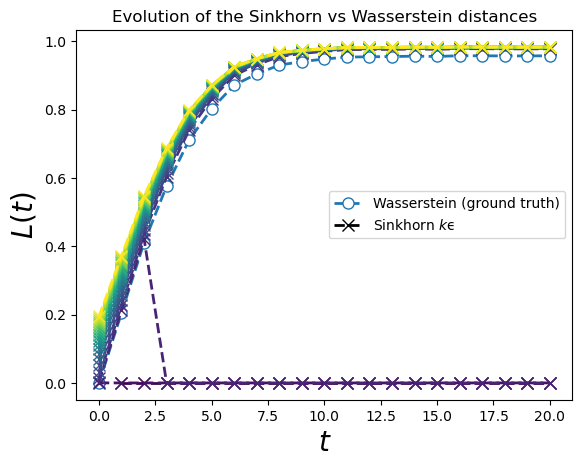

In [28]:
# Plot them

# Wasserstein distance (already computed in visualize_noising.ipynb)
dir, filename = get_path(config, type='wassdist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass = np.load(dir / filename)

# Sinkhorn distance
sink = np.zeros([n_regs+1, n_timesteps+1])
for i in range(n_regs+1):
    dir, filename = get_path(config, type='sinkdist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps, reg=i*epsilon)
    sink[i] = np.load(dir / filename)

plt.plot(wass, 'o--', label='Wasserstein (ground truth)', mfc='white', markersize=8, lw=2)

cmap = plt.get_cmap('viridis')
for i in range(0, n_regs+1):
    color = cmap(i / n_regs)
    plt.plot(sink[i], 'x--', mfc='white', markersize=8, lw=2, color=color)
plt.plot([], [], 'x--', label=r'Sinkhorn $k$ϵ', mfc='white', markersize=8, lw=2, color='black')

plt.ylabel(r'$L(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.title('Evolution of the Sinkhorn vs Wasserstein distances')
plt.legend()
None

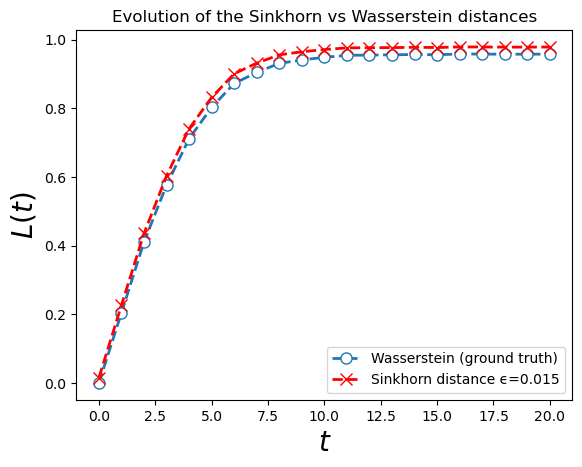

In [27]:
plt.plot(wass, 'o--', label='Wasserstein (ground truth)', mfc='white', markersize=8, lw=2)
i = 3
reg = i*epsilon
plt.plot(sink[i], 'x--', label=f'Sinkhorn distance ϵ={i*epsilon}', mfc='white', markersize=8, lw=2, color='red')

plt.ylabel(r'$L(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.title('Evolution of the Sinkhorn vs Wasserstein distances')
plt.legend()

In [32]:
# Difference between both distances at t=0:
result = sink[i,0] - wass[0]
print(f"{result:.4f}")
print(sink[i,0], wass[0])

0.1949
0.19492201507091522 2.2649766506788183e-09
